# Experiments on Qwen3 System Prompts

In [1]:
# import dependencies
import os

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from process_batch import ComparisonJob, Qwen3VLBatchProcessor
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
from utils import build_messages, calc_ranks


/home/sjkro1/anaconda3/envs/aesthetic-evolution/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load model and processor
processor = Qwen3VLBatchProcessor(
        model_name="Qwen/Qwen3-VL-7B-Instruct",
        device="cuda" if torch.cuda.is_available() else "cpu"
        )

Loading model Qwen/Qwen3-VL-7B-Instruct on cuda...


Loading checkpoint shards: 100%|██████████| 4/4 [00:06<00:00,  1.62s/it]


Model loaded successfully!


In [3]:
# extract data
data_df = pd.read_csv("curl_noise_03/data.csv")
n = 25
data = data_df.sample(n, random_state=472833)
filenames = data["id"].values

In [4]:
# plotting function
def plot_image_grid(filenames, ranks=None):
    fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
    for i in range(5):
        for j in range(5):
            idx = i * 5 + j
            img = plt.imread(os.path.join("curl_noise_03", filenames[idx]))
            ax[i, j].imshow(img)
            if ranks is not None:
                ax[i, j].set_title(f"{filenames[idx].split('_')[-1].strip('.png')} : {ranks[idx]}")
            else:
                ax[i, j].set_title(filenames[idx].split('_')[-1].strip('.png'))
            ax[i, j].axis('off')
    plt.tight_layout()
    plt.show()

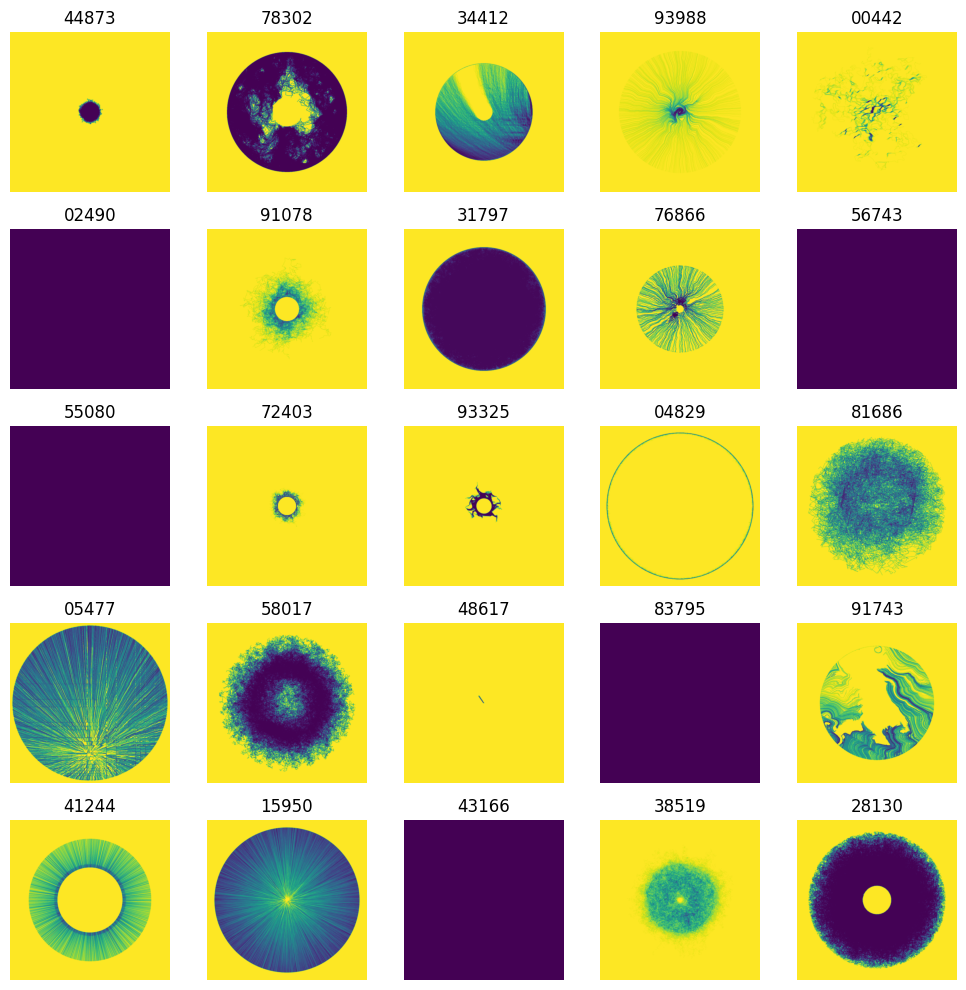

In [5]:
# plot images
plot_image_grid(filenames)

## Base Experiment

In [5]:
prompt = "You are an assistant that compares two images and ranks which one is more aesthetically pleasing. You will be given two images and you need to output either '1' or '2' based on which image is more aesthetically pleasing."
jobs = build_messages(filenames, "curl_noise_03", 25, prompt)

In [6]:
results = processor.process_batch_chunked(jobs, chunk_size=50)

Processing 300 jobs in chunks of 50...

Processing chunk 1/6 (50 jobs)
Processing 50 jobs in parallel on GPU...
Preparing batch inputs...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


torch.Size([50, 578])

VALIDATION CHECKS:
Number of jobs: 50
Number of text prompts: 50
Expected images (2 per job): 100
Batch size in inputs: 50
✓ All validation checks passed!

Generating responses for 50 jobs in parallel...
Generation completed in 3.79s
Time per job: 0.08s
Max GPU memory allocated: 25156.18 MB
Decoding outputs...
✓ Completed job comparison_0_1
✓ Completed job comparison_0_2
✓ Completed job comparison_0_3
✓ Completed job comparison_0_4
✓ Completed job comparison_0_5
✓ Completed job comparison_0_6
✓ Completed job comparison_0_7
✓ Completed job comparison_0_8
✓ Completed job comparison_0_9
✓ Completed job comparison_0_10
✓ Completed job comparison_0_11
✓ Completed job comparison_0_12
✓ Completed job comparison_0_13
✓ Completed job comparison_0_14
✓ Completed job comparison_0_15
✓ Completed job comparison_0_16
✓ Completed job comparison_0_17
✓ Completed job comparison_0_18
✓ Completed job comparison_0_19
✓ Completed job comparison_0_20
✓ Completed job comparison_0_21
✓ 

In [15]:
ranks = calc_ranks(results, n)
sorted_idx = np.argsort(ranks)[::-1]

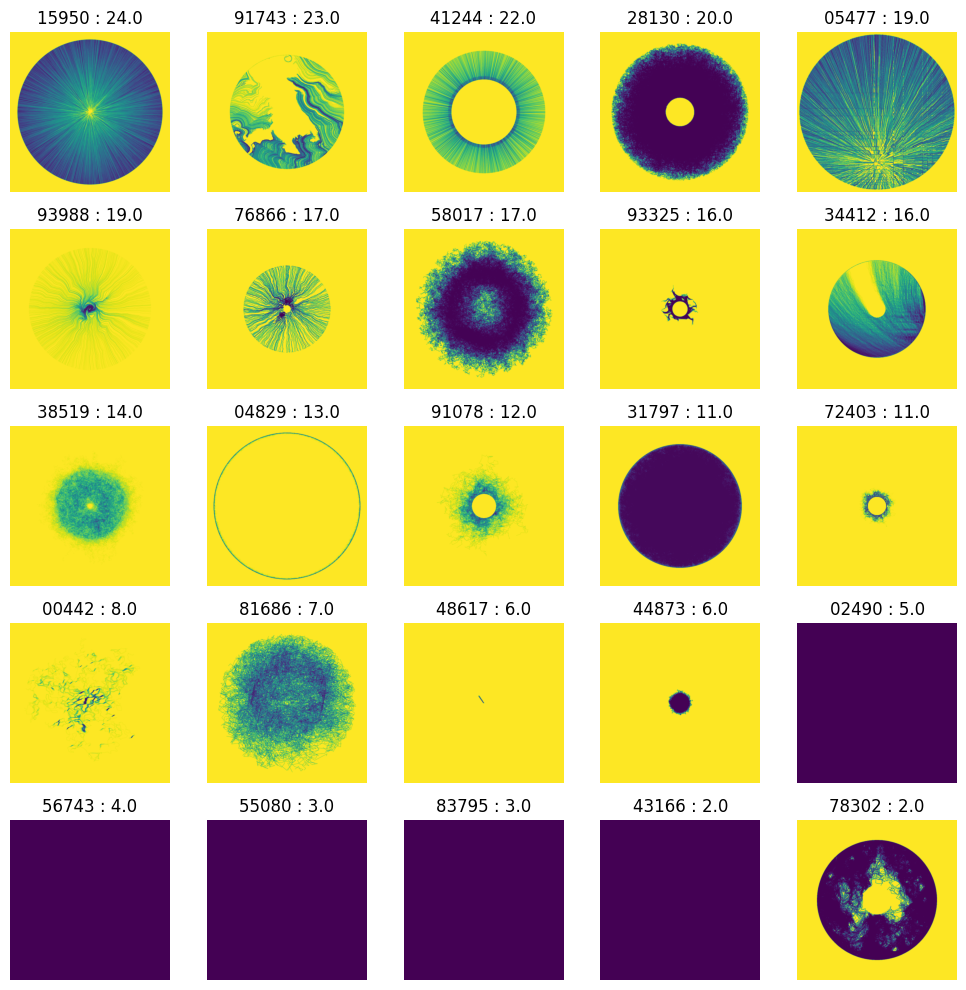

In [20]:
# plot sorted images
plot_image_grid(filenames[sorted_idx], ranks=ranks[sorted_idx])


## Penalise Blank Images

In [ ]:
prompt = "You are an assistant that compares two images and ranks which one is more aesthetically pleasing. You will be given two images and you need to output either '1' or '2' based on which image is more aesthetically pleasing. The criteria for aesthetics is up to you, however, you must penalise images with no design."
jobs = build_messages(filenames, "curl_noise_03", 25, prompt)

In [22]:
results = processor.process_batch_chunked(jobs, chunk_size=64)

Processing 300 jobs in chunks of 64...

Processing chunk 1/5 (64 jobs)
Processing 64 jobs in parallel on GPU...
Preparing batch inputs...
torch.Size([64, 602])

VALIDATION CHECKS:
Number of jobs: 64
Number of text prompts: 64
Expected images (2 per job): 128
Batch size in inputs: 64
✓ All validation checks passed!

Generating responses for 64 jobs in parallel...
Generation completed in 4.26s
Time per job: 0.07s
Max GPU memory allocated: 27887.62 MB
Decoding outputs...
✓ Completed job comparison_0_1
✓ Completed job comparison_0_2
✓ Completed job comparison_0_3
✓ Completed job comparison_0_4
✓ Completed job comparison_0_5
✓ Completed job comparison_0_6
✓ Completed job comparison_0_7
✓ Completed job comparison_0_8
✓ Completed job comparison_0_9
✓ Completed job comparison_0_10
✓ Completed job comparison_0_11
✓ Completed job comparison_0_12
✓ Completed job comparison_0_13
✓ Completed job comparison_0_14
✓ Completed job comparison_0_15
✓ Completed job comparison_0_16
✓ Completed job comparis

In [23]:
ranks = calc_ranks(results, n)
sorted_idx = np.argsort(ranks)[::-1]

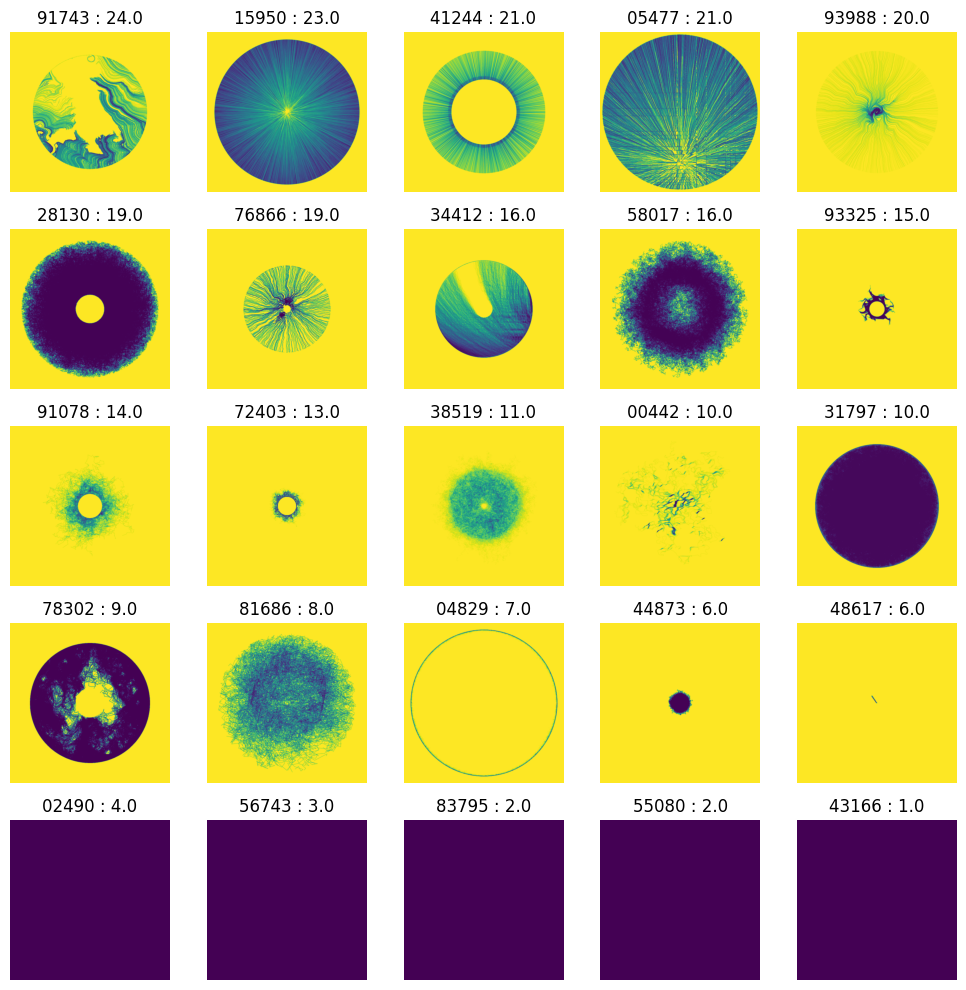

In [25]:
# plot sorted images
plot_image_grid(filenames[sorted_idx], ranks=ranks[sorted_idx])

## Increased Detail in Prompt

In [26]:
prompt = """You are an assistant that compares two images and ranks which one is more aesthetically pleasing.
You will be given two images and you need to output either '1' or '2' based on which image is more aesthetically pleasing.
The criteria for aesthetics that designs should be complex not simple, with emergent structures that are both beautiful
and novel. This opposed to boring or simple designs which are not aesthetically pleasing. You must also penalise images with no design."""

jobs = build_messages(filenames, "curl_noise_03", 25, prompt)

In [27]:
results = processor.process_batch_chunked(jobs, chunk_size=64)

Processing 300 jobs in chunks of 64...

Processing chunk 1/5 (64 jobs)
Processing 64 jobs in parallel on GPU...
Preparing batch inputs...
torch.Size([64, 627])

VALIDATION CHECKS:
Number of jobs: 64
Number of text prompts: 64
Expected images (2 per job): 128
Batch size in inputs: 64
✓ All validation checks passed!

Generating responses for 64 jobs in parallel...
Generation completed in 4.37s
Time per job: 0.07s
Max GPU memory allocated: 28274.48 MB
Decoding outputs...
✓ Completed job comparison_0_1
✓ Completed job comparison_0_2
✓ Completed job comparison_0_3
✓ Completed job comparison_0_4
✓ Completed job comparison_0_5
✓ Completed job comparison_0_6
✓ Completed job comparison_0_7
✓ Completed job comparison_0_8
✓ Completed job comparison_0_9
✓ Completed job comparison_0_10
✓ Completed job comparison_0_11
✓ Completed job comparison_0_12
✓ Completed job comparison_0_13
✓ Completed job comparison_0_14
✓ Completed job comparison_0_15
✓ Completed job comparison_0_16
✓ Completed job comparis

In [28]:
ranks = calc_ranks(results, n)
sorted_idx = np.argsort(ranks)[::-1]

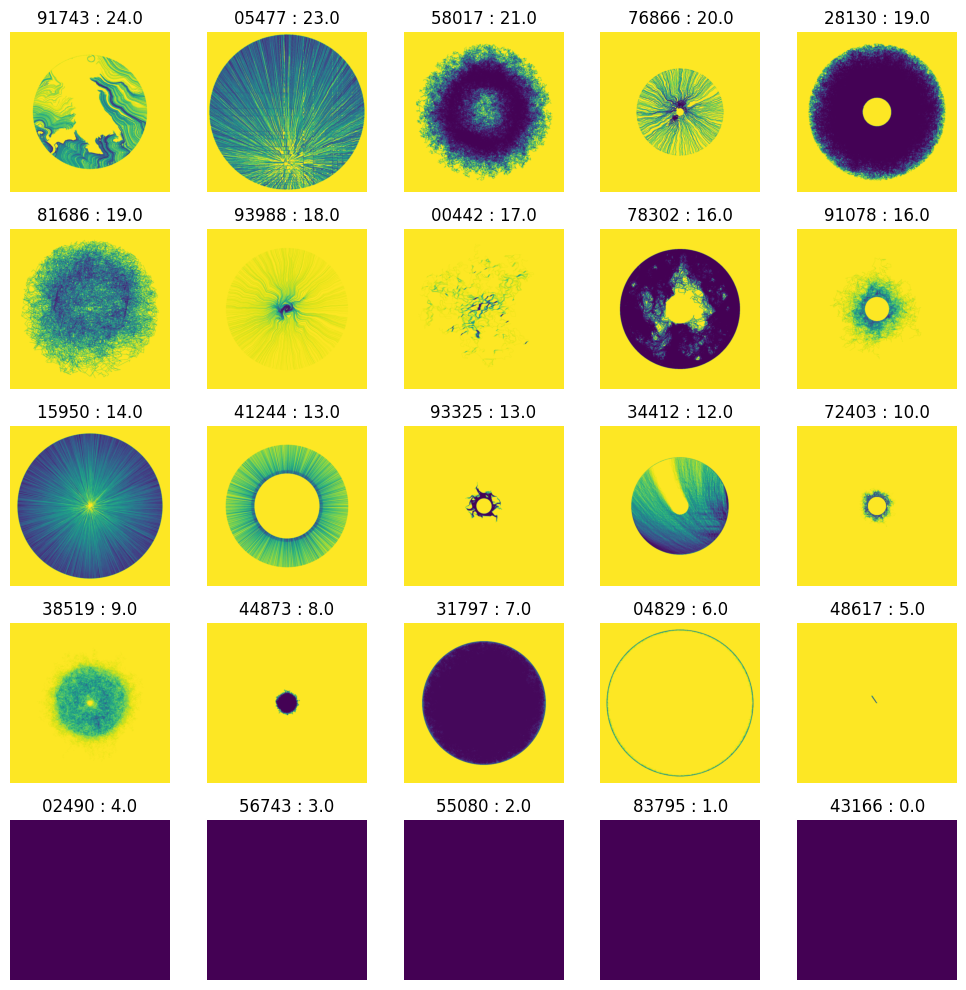

In [29]:
# plot sorted images
plot_image_grid(filenames[sorted_idx], ranks=ranks[sorted_idx])